1. [정답(Ground Truth)] 라벨 폴더를 선택하세요.
2. [비교 대상] 최상위 폴더를 선택하세요. (하위 모든 labels 폴더 검색)


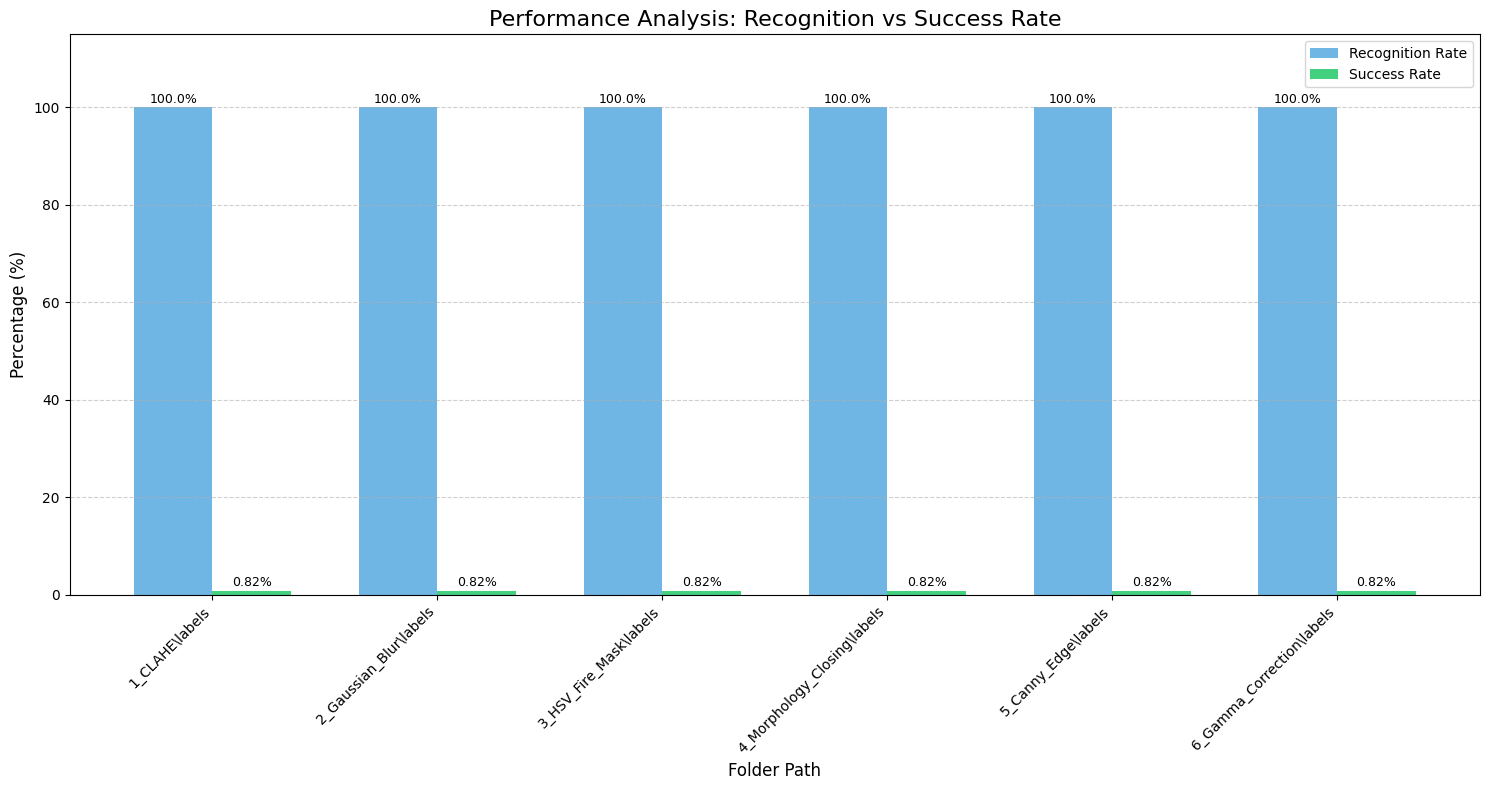

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tkinter import filedialog, Tk

def get_label_data(file_path):
    """라벨 파일 내용을 읽어 반환합니다."""
    if not os.path.exists(file_path):
        return None
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read().strip()
    except:
        return None

def analyze_folders(gt_dir, parent_pred_dir):
    results = []
    # 1. 정답 폴더에서 기준이 되는 .txt 파일 목록 추출
    gt_files = [f for f in os.listdir(gt_dir) if f.endswith('.txt')]
    total_gt_count = len(gt_files)
    
    if total_gt_count == 0:
        print("오류: 정답(GT) 폴더에 .txt 파일이 없습니다.")
        return []

    # 2. 모든 하위 폴더를 탐색하며 'labels' 폴더 찾기
    for root, dirs, files in os.walk(parent_pred_dir):
        if os.path.basename(root).lower() == 'labels':
            # 정답 폴더 자체는 제외
            if os.path.abspath(root) == os.path.abspath(gt_dir):
                continue
            
            folder_path_display = os.path.relpath(root, parent_pred_dir)
            
            detected_count = 0  # 라벨 파일이 생성된 개수 (인식됨)
            success_count = 0   # 내용까지 일치하는 개수 (성공)
            
            # 3. 정답 파일 리스트를 기준으로 현재 폴더와 비교
            for gt_file in gt_files:
                gt_content = get_label_data(os.path.join(gt_dir, gt_file))
                pred_path = os.path.join(root, gt_file)
                pred_content = get_label_data(pred_path)
                
                if pred_content is not None:
                    detected_count += 1  # 파일이 존재하면 일단 인식된 것으로 간주
                    if gt_content == pred_content:
                        success_count += 1  # 내용까지 같으면 성공
            
            # 인식률: 정답 대비 파일 생성 비율
            recognition_rate = (detected_count / total_gt_count * 100) if total_gt_count > 0 else 0
            # 성공률: 정답 대비 정확히 맞춘 비율
            success_rate = (success_count / total_gt_count * 100) if total_gt_count > 0 else 0
            
            results.append({
                'Path': folder_path_display,
                'Recognition Rate (%)': round(recognition_rate, 2),
                'Success Rate (%)': round(success_rate, 2),
                'Total GT': total_gt_count,
                'Detected': detected_count,
                'Success': success_count
            })
            
    return results

def main():
    root = Tk()
    root.withdraw()

    print("1. [정답(Ground Truth)] 라벨 폴더를 선택하세요.")
    gt_dir = filedialog.askdirectory(title="정답 라벨 폴더 선택")
    
    print("2. [비교 대상] 최상위 폴더를 선택하세요. (하위 모든 labels 폴더 검색)")
    parent_pred_dir = filedialog.askdirectory(title="전처리 결과 최상위 폴더 선택")

    if not gt_dir or not parent_pred_dir:
        print("취소되었습니다.")
        return

    analysis_data = analyze_folders(gt_dir, parent_pred_dir)
    
    if not analysis_data:
        print("분석할 'labels' 폴더를 찾지 못했습니다.")
        return

    df = pd.DataFrame(analysis_data).sort_values(by='Success Rate (%)', ascending=False)

    # 시각화 (인식률 vs 성공률 비교 그래프)
    plt.figure(figsize=(15, 8))
    
    x = range(len(df))
    width = 0.35  # 막대 너비

    # 인식률과 성공률 두 개의 막대 그래프
    plt.bar([i - width/2 for i in x], df['Recognition Rate (%)'], width, label='Recognition Rate', color='#3498db', alpha=0.7)
    plt.bar([i + width/2 for i in x], df['Success Rate (%)'], width, label='Success Rate', color='#2ecc71', alpha=0.9)

    plt.title('Performance Analysis: Recognition vs Success Rate', fontsize=16)
    plt.xlabel('Folder Path', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(x, df['Path'], rotation=45, ha='right')
    plt.ylim(0, 115)
    plt.legend()

    # 막대 위에 수치 표시
    for i, row in enumerate(df.itertuples()):
        plt.text(i - width/2, row._2 + 1, f'{row._2}%', ha='center', fontsize=9)
        plt.text(i + width/2, row._3 + 1, f'{row._3}%', ha='center', fontsize=9)

    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

if __name__ == "__main__":
    main()